# **A SIMULATION OF BEE POPULATION EVOLUTION**

* This model simulates the evolution of a bee-pollen ecosystem which governed by some behavioural rules.
* This code is the visual representation of such system. 
* Click on **Run All** button to execute.
* It also plots graphs like total number of bees _v/s_ time.
* Close the _pygame_ window to see the plots.

### **IMPORTING REQUIRED LIBRARIES :**

In [2]:
import pygame
import math
import matplotlib.pyplot as plt
import random

pygame-ce 2.5.7 (SDL 2.32.10, Python 3.14.4)


### **IMPORTANT CONSTANTS:**

It contains certain important constants used throughout the code.
* HEIGHT, WIDTH
* POLLEN_MAP stores the colour of the pollen source according to the quality: _red_ for 1, _blue_ for 5, _white_ for 10.
* QUALITY_MAP stores the QI of the pollen.
* NUMBER OF BEES, NUMBER OF POLLENS

In [3]:
HEIGHT = 720
WIDTH = 1280
POLLEN_MAP={1:"red", 5:"blue", 10:"white"}
QUALITY_MAP={1:1e-6, 5:1e-8, 10:1e-10}
NUM_BEES = 50
NUM_POLLENS = 10

### **CLASS DEFINITIONS:**

* It contains the class **PollenSource** and **Bee**. 
* The PollenSource class stores the information about the pollen sources such as their position, quality, color, nectar and also contains _update()_ and _draw()_ functions which helps to create the blinking effect of the pollen source when it collides with a pollen source.
* The Bee class stores the information about the bees such as their preference, position, reward they have collected, their current target, age and whether they have reproduced or not. It also contains functions like _move()_ which helps in their moevement, _collide()_ which takes necessary action if it has collided with any pollen or not. It also contains _reproduce()_ and _dies()_ functions which, as the name suggests, uses a probabilistic approach to check whether a bee reproduces or dies. Its probabiliity of reporduction used varies as _ln(1+fitness)_ and also introduces the concept of mutation. The probability of death varies as _1 - exp(-QI x age)_ upto a certain age where _QI_ is the quality index (more the quality index more is the chance of survival).

In [4]:
class PollenSource :
    def __init__(self) :
        self.pos = [random.randrange(50, WIDTH-50, 50), random.randrange(50, HEIGHT-50, 50)]
        self.quality = random.choice([1, 5, 10])
        self.color = POLLEN_MAP[self.quality]   
        self.nectar = random.choice([5, 6, 7, 8, 9, 10]) 
        self.blink_timer = 0

    def update(self):
        if self.blink_timer > 0:
            self.blink_timer -= 1

    def draw(self, screen):
        pygame.draw.circle(screen, self.color, self.pos, 10)
        if self.blink_timer > 0 and (self.blink_timer // 5)%2 == 0:
            pygame.draw.circle(screen, "yellow", self.pos, 13, 2)

        

class Bee :
    def __init__(self, preference=None) :
        self.preference = preference
        self.pos = [random.randint(50, WIDTH-50), random.randint(50, HEIGHT-50)]
        self.collected_reward = 0.0
        self.target = None
        self.age = 0
        self.has_reproduced = False

    def move(self, pollens, bees):
        moved = False

        if self.preference is not None and random.random() < 0.8: # move towards the preferred pollen 80% of the time
            preferred = [p for p in pollens if p.quality == self.preference] # selects the preferred pollens and stores it in the list

            for candidate in preferred :
                if not any(b is not self and b.target == candidate for b in bees):
                    self.target = candidate
                    break

            if self.target is None and pollens:
                self.target = min(pollens, key = lambda p: (p.pos[0] - self.pos[0])**2 + (p.pos[1] - self.pos[1])**2)
            dx = self.target.pos[0] - self.pos[0]
            dy = self.target.pos[1] - self.pos[1]
            dist = math.hypot(dx, dy)
            
            if dist!=0 : 
                self.pos[0] += int(math.ceil(dx/dist))
                self.pos[1] += int(math.ceil(dy/dist))

                moved = True

        if not moved:    
            dx, dy = random.choice([-4, -3, -2, -1, 0, 1, 2, 3, 4]), random.choice([-4, -3, -2, -1, 0, 1, 2, 3, 4])
            self.pos[0] += dx
            self.pos[1] += dy  

            if self.pos[0] < 0:
                self.pos[0] = 0
                dx = -dx 
            elif self.pos[0] > WIDTH:
                self.pos[0] = WIDTH
                dx = -dx

            if self.pos[1] < 0:
                self.pos[1] = 0
                dy = -dy
            elif self.pos[1] > HEIGHT:
                self.pos[1] = HEIGHT
                dy = -dy 

    def collide(self, pollen) :
        d = math.hypot(self.pos[0]-pollen.pos[0], self.pos[1]-pollen.pos[1])

        if d < 15:
            self.collected_reward+=pollen.quality
            self.preference = pollen.quality
            pollen.nectar-=1
            pollen.blink_timer = 15
            
            if d != 0:
                self.pos[0] += int(4 * (self.pos[0] - pollen.pos[0]) / d)
                self.pos[1] += int(4 * (self.pos[1] - pollen.pos[1]) / d)
            
            return True
        return False
    
    def reproduce(self) :

        fitness = self.collected_reward
        if fitness > 0 and random.random() < min(0.05 * math.log1p(fitness), 0.5) and self.has_reproduced is False:
            self.has_reproduced = True # so that each bee can have only child at max
            
            prob = random.random() # introducing mutation with 1% chance
            if prob < 0.99: 
                return self.preference
            else :
                return random.choice([1, 5, 10])
        return -1
    
    def dies(self) :
        age = self.age
        pref = self.preference
        prob = random.random()
        if pref is not None : 
            if prob <= 1 - math.exp(-QUALITY_MAP[pref]*age) : 
                return True
            else :
                return False
        elif age >=720 and prob < 1e-5:
            return True
        else : return False
        


### **SETTING UP THE PYGAME WINDOW**

* Here is where the actual loop runs and shows the animation of the bee-pollen model. 
* Clicking on the red cross on the top right of the window closes the _pygame_ window.

In [5]:
pygame.init()
screen = pygame.display.set_mode((WIDTH, HEIGHT))
clock = pygame.time.Clock() #setting up the clock
running = True

pollens=[]
bees=[]

# These will be required for the plotting of the graph
avg_rewards=[]
num_bees_at_instant=[]
num_pref={1:[], 5:[], 10:[]}

iterations=[]

# Initializing the number of pollens and bees

for i in range(NUM_POLLENS) :
    pollens.append(PollenSource()) 


for i in range(NUM_BEES) :
    bees.append(Bee())

font = pygame.font.SysFont("comicsans", 15) 
t = 0 # this variable stores the number of ticks

while running :
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False

    screen.fill("black")

    for p in pollens:
        pygame.draw.circle(screen, p.color, p.pos, 10)

    survived=[] # This list will store the bees tht survived the current iteration

    for b in bees :
        b.move(pollens, bees)
        b.age += 1
        
        if b.dies() : 
            continue
        survived.append(b)

        pref = b.reproduce()
        if pref!=-1:
            new_bee = Bee(preference=pref)
            new_bee.pos = b.pos
            survived.append(new_bee)

        for p in pollens:
            b.collide(p)
            if p.nectar <= 0: # when nectar falls down to 0, another random pollen source respawns at a random location
                p.pos = [random.randrange(50, WIDTH-50, 50), random.randrange(50, HEIGHT-50, 50)]
                p.quality = random.choice([1, 5, 10])
                p.color = POLLEN_MAP[p.quality]
                p.nectar = random.choice([5, 6, 7, 8, 9, 10])

        pygame.draw.circle(screen, "yellow", b.pos, 5)

        for p in pollens :
            p.update()
            p.draw(screen)

    bees = survived

    if bees :
        avg_rewards.append(sum(b.collected_reward for b in bees)/len(bees))
        iterations.append(len(iterations))

    cnt1=cnt5=cnt10=0
    for b in bees :
        if b.preference == 1 : cnt1+=1
        elif b.preference == 5 : cnt5+=1
        elif b.preference == 10 : cnt10+=1

    num_pref[1].append(cnt1)
    num_pref[5].append(cnt5)
    num_pref[10].append(cnt10)

    text_bees = font.render(f'Number of bees : {len(bees)}', True, "white")
    text_time = font.render(f'Time : {t//60}s', True, "white")
    screen.blit(text_bees, (WIDTH - 150, HEIGHT - 40))
    screen.blit(text_time, (WIDTH - 150, HEIGHT - 20))

    t+=1

    num_bees_at_instant.append(len(bees)) 
    
    pygame.display.flip() #flips the display
    clock.tick(60) # sets fps to 60

pygame.quit()

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [112 lines of output]
      Skipping Cython compilation
      
      
      WARNING, No "Setup" File Exists, Running "buildconfig/config.py"
      Using WINDOWS configuration...
      
      Making dir :prebuilt_downloads:
      Downloading... https://www.libsdl.org/release/SDL2-devel-2.28.4-VC.zip 25ef9d201ce3fd5f976c37dddedac36bd173975c
      Unzipping :prebuilt_downloads\SDL2-devel-2.28.4-VC.zip:
      Downloading... https://www.libsdl.org/projects/SDL_image/release/SDL2_image-devel-2.0.5-VC.zip 137f86474691f4e12e76e07d58d5920c8d844d5b
      Unzipping :prebuilt_downloads\SDL2_image-devel-2.0.5-VC.zip:
      Downloading... https://github.com/libsdl-org/SDL_ttf/releases/download/release-2.20.1/SDL2_ttf-devel-2.20.1-VC.zip 371606aceba450384428fd2852f73d2f6290b136
      Unzipping :prebuilt_downloads\SDL2_ttf-devel-2.20.1-VC.zip:
      Downloading... https://g

     ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/14.8 MB 2.1 MB/s eta 0:00:07
     -- ------------------------------------- 0.8/14.8 MB 1.5 MB/s eta 0:00:10
     ----- ---------------------------------- 2.1/14.8 MB 3.2 MB/s eta 0:00:04
     --------- ------------------------------ 3.4/14.8 MB 4.1 MB/s eta 0:00:03
     ------------- -------------------------- 5.0/14.8 MB 4.8 MB/s eta 0:00:03
     ---------------- ----------------------- 6.3/14.8 MB 5.1 MB/s eta 0:00:02
     -------------------- ------------------- 7.6/14.8 MB 5.3 MB/s eta 0:00:02
     ------------------------ --------------- 9.2/14.8 MB 5.6 MB/s eta 0:00:02
     ---------------------------- ----------- 10.5/14.8 MB 5.8 MB/s eta 0:00:01
     ----------------------------- ---------- 11.0/14.8 MB 5.5 MB/s eta 0:00:01
     ------------------------------- -------- 11.8/14.8 MB 5.2 M

### **Matplotlib plots:**

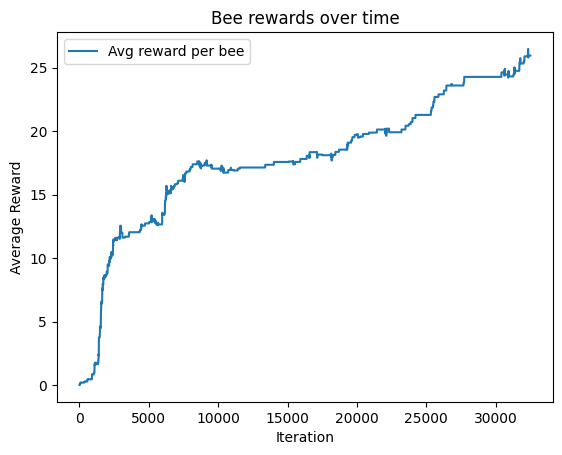

In [6]:
plt.plot(iterations, avg_rewards, label = "Avg reward per bee")
plt.xlabel("Iteration")
plt.ylabel("Average Reward")
plt.title("Bee rewards over time")
plt.legend()
plt.show()

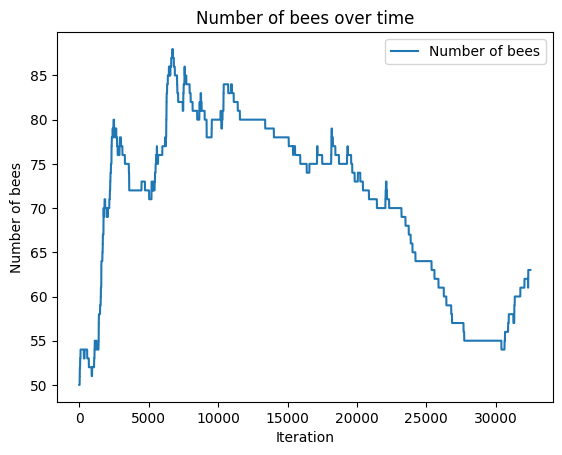

In [7]:
plt.plot(iterations, num_bees_at_instant, label = "Number of bees")
plt.xlabel("Iteration")
plt.ylabel("Number of bees")
plt.title("Number of bees over time")
plt.legend()
plt.show()

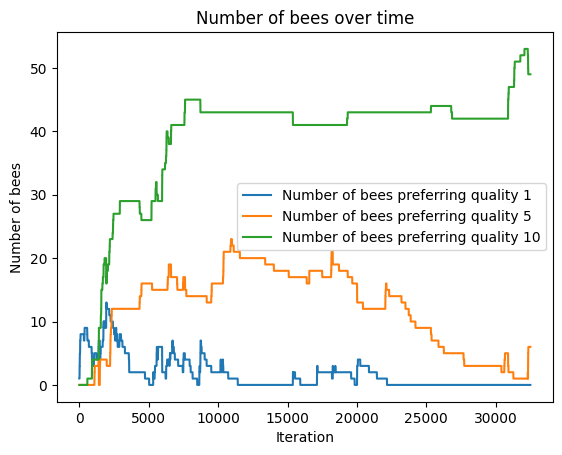

In [8]:
plt.plot(iterations, num_pref[1], label = "Number of bees preferring quality 1")
plt.plot(iterations, num_pref[5], label = "Number of bees preferring quality 5")
plt.plot(iterations, num_pref[10], label = "Number of bees preferring quality 10")
plt.xlabel("Iteration")
plt.ylabel("Number of bees")
plt.title("Number of bees over time")
plt.legend()
plt.show()